![logo](https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/docs/source/_figures/Helmholtz-AI.png?raw=true)

# Hand-On Session: Exploratory Data Analysis

This notebook we will explore a **real-world gene expression dataset** centered on **Acute Myeloid Leukemia (AML)**. The data originates from [Warnat-Herresthal et al. (2020)](https://doi.org/10.1016/j.isci.2019.100780), *"Scalable prediction of acute myeloid leukemia using high-dimensional machine learning and blood transcriptomics."* The objectives of this notebook are to load, preprocess, and explore the RNA-seq AML dataset in order to understand its structure, class balance, and potential confounding factors through exploratory data analysis (EDA).

--------

## Getting Started

### Setup Colab environment

If you installed the packages and requirements on your own machine, you can skip this section and start from the import section.
Otherwise, you can follow and execute the tutorial on your browser. In order to start working on the notebook, click on the following button. This will open this page in the Colab environment and you will be able to execute the code on your own.

<a href="https://colab.research.google.com/github/HelmholtzAI-Consultants-Munich/XAI-Tutorials/blob/main/xai-for-random-forest/Bio-5-HandsOn_AML_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Now that you opened the notebook in Colab, follow the next step:

1. Run this cell to connect your Google Drive to Colab and install packages
2. Allow this notebook to access your Google Drive files. Click on 'Yes', and select your account.
3. "Google Drive for desktop wants to access your Google Account". Click on 'Allow'.
   
At this point, a folder has been created in your Drive and you can navigate it through the lefthand panel in Colab, you might also have received an email that informs you about the access on your Google Drive.

In [ ]:
# On Google Colab: fetch the course and install the requirements.
# Running locally this cell does nothing, because you already have the repository
# and installed the requirements yourself.
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %cd /content
    !rm -rf XAI-Tutorials
    !git clone --depth 1 --branch main https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials.git
    %cd XAI-Tutorials
    !pip install -r requirements_xai-for-random-forest.txt
    %cd xai-for-random-forest


### Imports

Let's start with importing all required Python packages.

In [1]:
# Load the required packages
import os
import sys
import pickle
import requests

import numpy as np
import pandas as pd

from collections import Counter

sys.path.append('./')
import utils

Now, we set the random seeds to ensure reproducible results, as we work with (pseudo) random numbers.

In [2]:
# assert reproducible random number generation
seed = 1
np.random.seed(seed)

## Dataset Description

The data originates from [Warnat-Herresthal et al. (2020)](https://doi.org/10.1016/j.isci.2019.100780), *"Scalable prediction of acute myeloid leukemia using high-dimensional machine learning and blood transcriptomics."*

The original study constructed a large multi-study dataset through a systematic search of the GEO database, followed by multiple filtering steps (cell type, species, platform, minimum sample size, and expert curation), as illustrated in the figure below. After removal of duplicates and exclusion of studies using sorted cell populations, three platform-specific datasets were established.

In this hands-on session, we focus exclusively on **Dataset 3 (RNA-seq)**, which contains:

- **1,181 samples**
- **AML patients**
- **Non-AML samples**, including:
  - Healthy individuals  
  - Other leukemia subtypes (e.g., ALL, CLL, CML, MDS)  
  - Other non-leukemic diseases  

The dataset includes **log2-transformed, normalized gene expression values** for over **12,000 genes**. In the original study, all datasets were harmonized to a shared gene set (12,708 genes) to enable cross-platform comparisons. Each dataset was normalized independently per platform prior to downstream analysis. Gene expression profiling was performed on **Peripheral Blood Mononuclear Cells (PBMC)** and **Bone Marrow (BM)** samples. In the original study, these tissues were considered equivalent for AML diagnosis and analyzed jointly.

For this hands-on session, we use the normalized RNA-seq data as provided and focus on modelling and interpretability rather than preprocessing.

<div>
<center><img src="https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/raw/main/docs/source/_figures/aml_case_study_1.jpg" width="600"/><center>
</div>

<font size=1> Source: [Warnat-Herresthal et al. (2020)](https://doi.org/10.1016/j.isci.2019.100780)

## Data Loading

The original AML datasets are provided within a Docker image made publicly available by the authors of [Warnat-Herresthal et al. (2020)](https://doi.org/10.1016/j.isci.2019.100780). To extract and prepare the datasets for use in Python, follow these steps:

1. **Pull the Docker image** containing the bundled data:

   ```bash
   docker pull schultzelab/aml_classifier:0.1
   ```

2. **Run the image interactively**:

   ```bash
   docker run --name aml_it -it schultzelab/aml_classifier:0.1 bash
   ```

3. **Copy the datasets from the Docker container to your local machine**:

   ```bash
   docker cp aml_it:/data ./ 
   ```

4. **Extract individual datasets from the RData files**:

   * Open the `.RData` files in **R**.
   * Convert the datasets (e.g., `dataset1`, `dataset2`, etc.) to CSV format for compatibility with Python:

     ```r
     write.csv(dataset1, file = "AML_data_1.csv", row.names = FALSE)
     ```

After completing these steps, you can load the exported CSV files in Python.


In [3]:
output_dir = "aml_case_study"
os.makedirs(output_dir, exist_ok=True)

url = "https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/releases/download/v2.0.0/AML_data_3.csv.zip"
with open(os.path.join(output_dir, "AML_data_3.csv.zip"), "wb") as f:
    f.write(requests.get(url).content)

url = "https://github.com/HelmholtzAI-Consultants-Munich/XAI-Tutorials/releases/download/v2.0.0/AML_data_3_info.csv"
with open(os.path.join(output_dir, "AML_data_3_info.csv"), "wb") as f:
    f.write(requests.get(url).content)

In [4]:
# Load metadata and labels
dataset3_info = pd.read_csv(os.path.join(output_dir, "AML_data_3_info.csv"))

# Load features
dataset3_features = pd.read_csv(os.path.join(output_dir, "AML_data_3.csv.zip"), compression='zip', index_col="sample_id")
dataset3_features = dataset3_features.T
dataset3_features["sample_id"] = dataset3_features.index
dataset3_features.reset_index(inplace=True, drop=True)

## Data Processing

In this step, we process the RNA-Seq dataset by loading and merging gene expression features with the associated sample metadata, followed by several data cleaning operations to ensure consistency and usability.
After this step, we obtain a clean dataset suitable for exploratory data analysis, modeling, and explainability workflows. The dataset is saved as pickle file.

In [5]:
# Merge labels and features by sample id
dataset3 = pd.merge(dataset3_features, dataset3_info, on="sample_id", how = "inner")
dataset3.drop(["FAB", "Filename"], axis=1, inplace=True)

# Fix some naming issues
dataset3.loc[dataset3['Tissue'] == ' IgA (Bergers) PBMC', 'Tissue'] = "PBMC"
dataset3.loc[dataset3['Tissue'] == ' IgA (Bergers)PBMC', 'Tissue'] = "PBMC"
dataset3.loc[dataset3['Tissue'] == ' PBMC', 'Tissue'] = "PBMC"
dataset3.loc[dataset3['Disease'] == 'healthy', 'Disease'] = "Healthy"
dataset3.loc[dataset3['Disease'] == 'influenca vaccination', 'Disease'] = "Influenca vaccination"

dataset3[["Condition", "Disease", "GSE", "sample_id", "Tissue"]] = dataset3[["Condition", "Disease", "GSE", "sample_id", "Tissue"]].astype("category")
dataset3['Condition'] = dataset3['Condition'].map({"CONTROL": '0_Control', "CASE": '1_Cancer'})
dataset3.sort_values(by=["Disease", "GSE"], inplace=True)
dataset3.head()

,PAX8,CCL5,MMP14,DTX2P1-UPK3BP1-PMS2P11,BAD,PRPF8,CAPNS1,RPL35,EIF4G2,EIF3D,...,ACTB,GAPDH,MIR3648-2,MIR3648-1,sample_id,Dataset,GSE,Condition,Disease,Tissue
55,429.141908,679.596678,46.224306,937.959260,1608.761060,27720.632747,12820.855077,13999.225407,30957.224082,14112.165495,...,207249.750988,265747.017753,17.718712,17.718712,GSM1202460,3,Simon (GSE49601),0_Control,ALL,PBMC
56,342.484974,770.785271,184.880818,2558.886562,1188.066680,24220.254267,12869.839728,13935.471198,18645.105479,10982.375835,...,91774.333718,38670.101249,17.562749,17.562749,GSM1202461,3,Simon (GSE49601),0_Control,ALL,BM
57,346.029244,178.616938,119.287279,1148.201355,697.178980,18303.955572,7988.833487,4892.082001,28528.632335,8830.426446,...,158699.288796,82700.438196,6.077328,6.077328,GSM1202462,3,Simon (GSE49601),0_Control,ALL,PBMC
58,273.100560,105.789293,51.844630,857.681016,534.301040,13737.032555,4964.479248,21213.436597,20873.148863,7660.995693,...,81507.355855,113369.609393,1.480776,1.480776,GSM1202463,3,Simon (GSE49601),0_Control,ALL,BM
59,219.733952,815.029434,43.389352,951.904754,349.511528,13659.251313,4370.811721,7804.724654,38471.198612,5333.294820,...,69913.344447,50200.238258,3.196909,3.196909,GSM1202464,3,Simon (GSE49601),0_Control,ALL,BM


In [6]:
with open(os.path.join(output_dir, "dataset3.pickle"), 'wb') as handle:
    pickle.dump(dataset3, handle, protocol=pickle.HIGHEST_PROTOCOL)

## Exploratory Data Analysis

Before developing predictive models, we conduct an **exploratory data analysis (EDA)** to gain a deeper understanding of the dataset’s composition, structure, and potential sources of bias. This step is critical for **identifying confounding factors**, ensuring **model robustness**, and improving **interpretability**.

Specifically, we aim to:

* **Assess class distribution**:
  We evaluate the frequency of each target class (e.g., control vs. cancer) to determine if the dataset is imbalanced. Class imbalance can skew model performance and lead to misleading conclusions.

* **Inspect metadata distributions**:
  We examine key metadata attributes such as:

  * **Tissue type** (e.g., bone marrow, PBMC),
  * **Study origin** (GEO accession numbers), and
  * **Disease subtype** (e.g., AML, CLL, CML, MDS)
    to understand the diversity and representation of biological and technical conditions in the dataset.

* **Visualize potential batch effects**:
  Using dimensionality reduction techniques like PCA and UMAP, we project the high-dimensional gene expression space into two dimensions. Coloring by metadata features (e.g., study or tissue) helps identify patterns that may reflect batch effects or non-biological variation.

* **Check for feature variability and missing values**:
  Although the dataset is already normalized and cleaned, it’s important to confirm the absence of missing values and assess the overall variance of gene expression across samples.

Through this EDA, we aim to ensure that our downstream analyses and model interpretations are not biased by hidden structure in the data and that **biological signals**—not technical artifacts—drive the patterns we uncover.

In [7]:
print(f"Number of missing values in the dataset: {sum(dataset3.isnull().sum())}")
print(f"Number of genes in the dataset: {dataset3.shape[1]}")
print(f"Number of samples in the dataset: {dataset3.shape[0]}")
print(f"Number of studies in the dataset: {len(Counter(dataset3['GSE']))}")
print(f"Number of disease types in the dataset: {len(Counter(dataset3['Disease']))}")

Number of missing values in the dataset: 0
Number of genes in the dataset: 12714
Number of samples in the dataset: 1181
Number of studies in the dataset: 23
Number of disease types in the dataset: 31


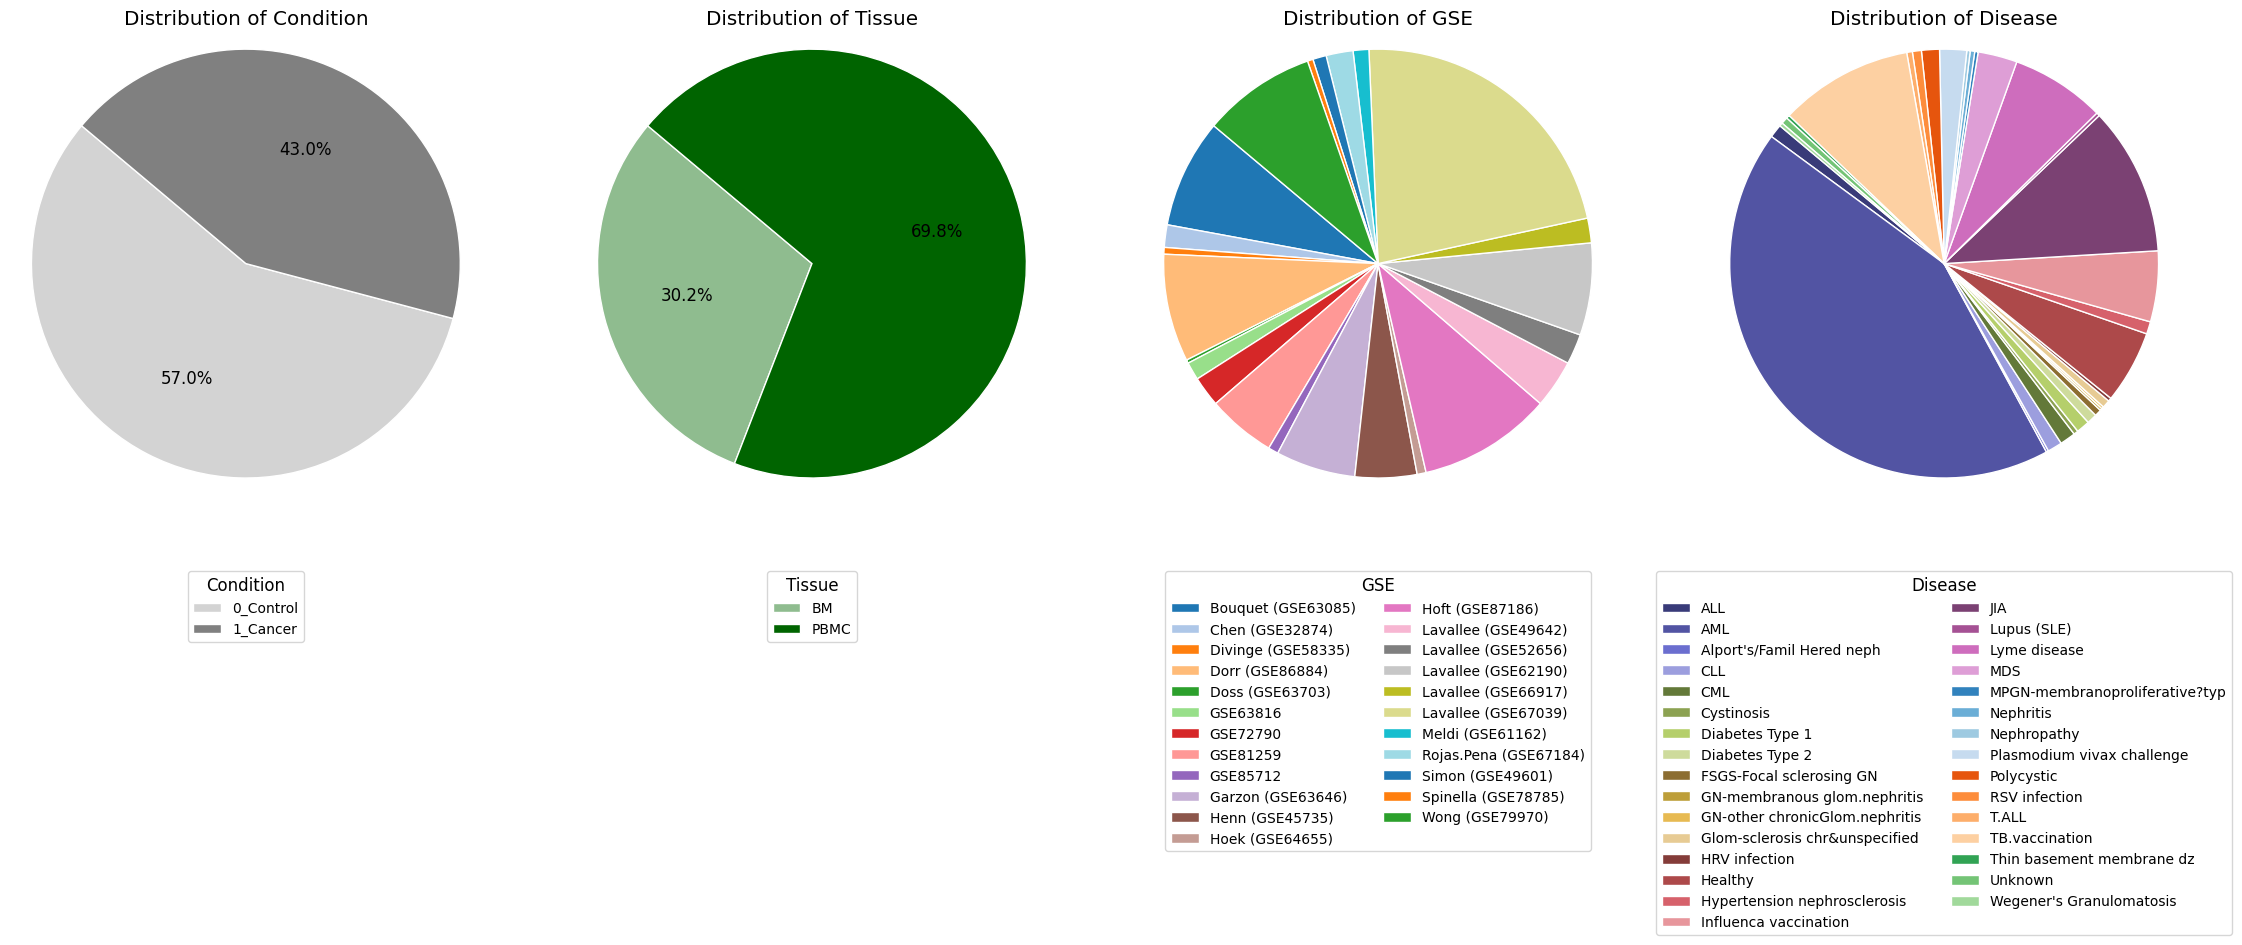

In [8]:
utils.plot_pie_charts(dataset3, name="case_study_1")

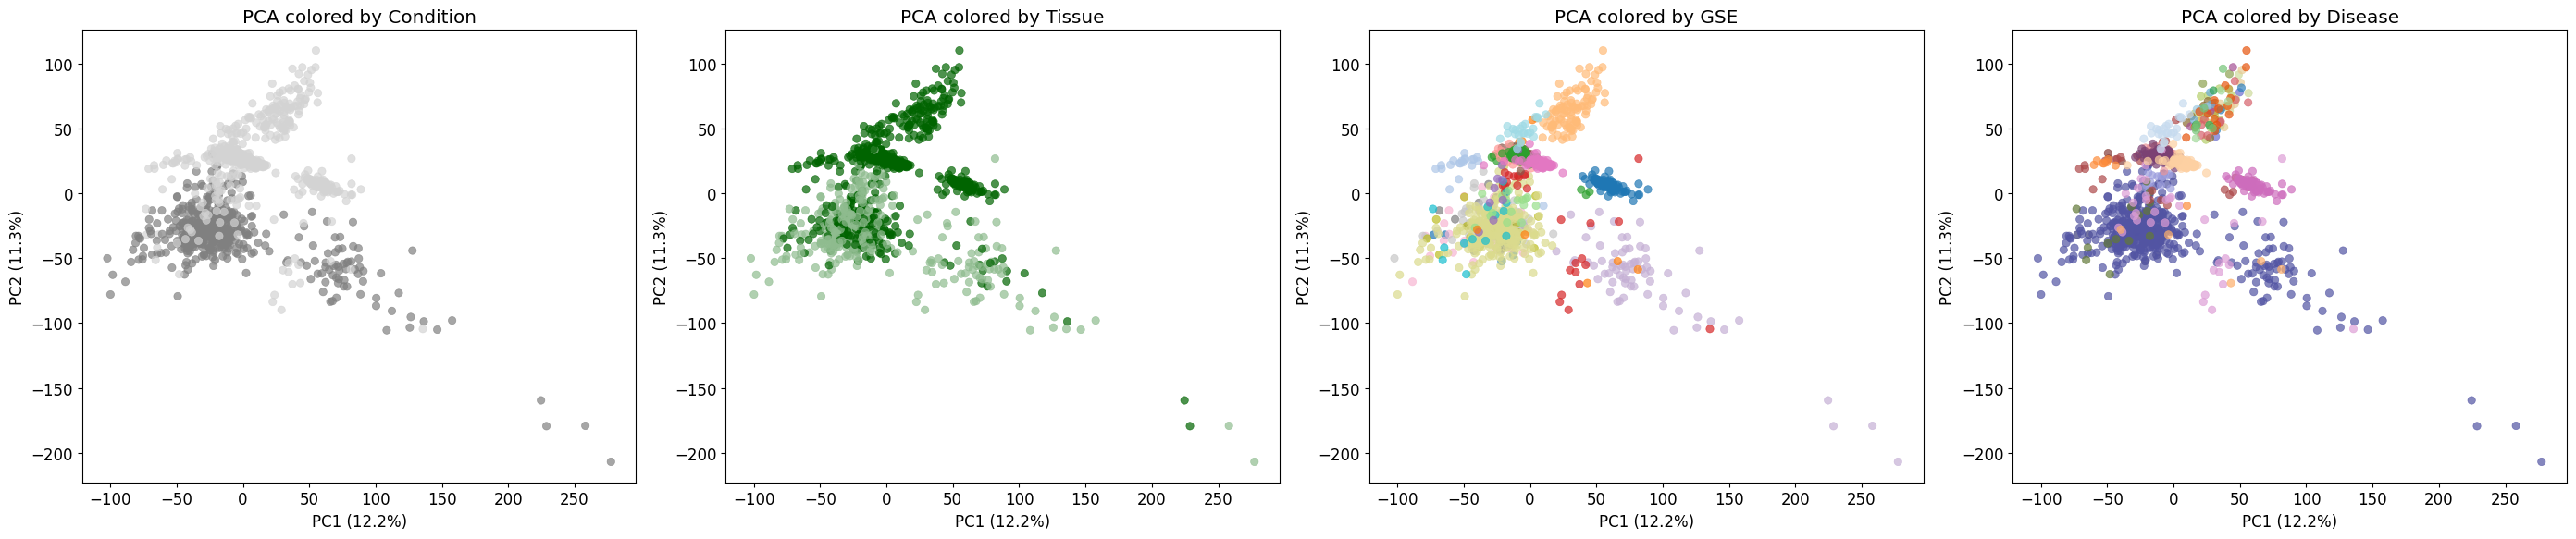

In [9]:
utils.plot_pca(dataset3, name="case_study_1")

/opt/anaconda3/envs/xai/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


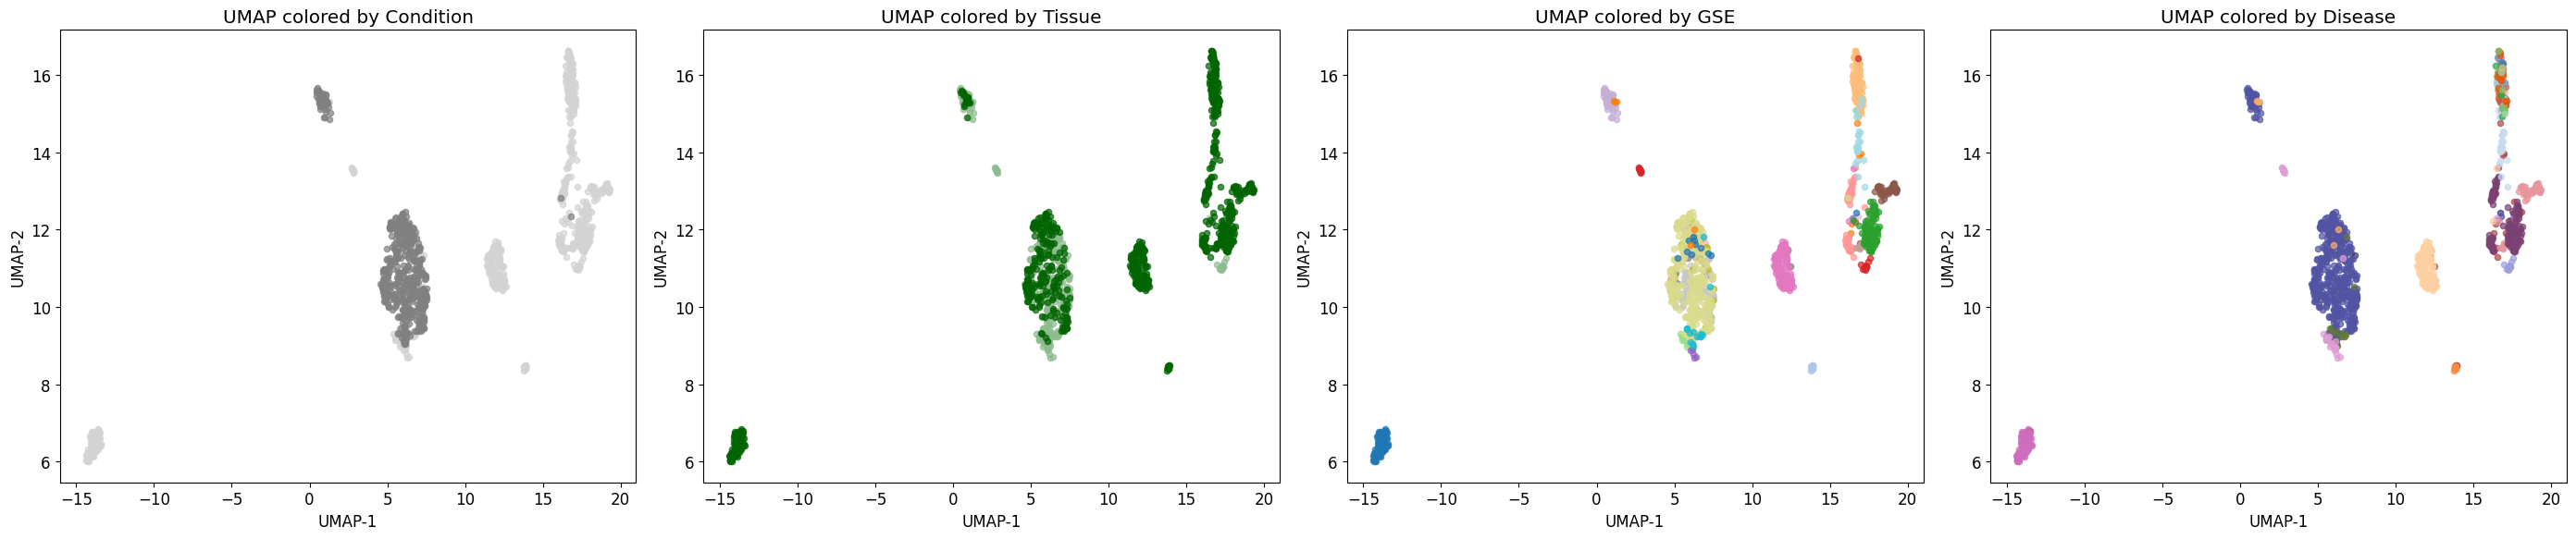

In [10]:
utils.plot_umap(dataset3, name="case_study_1")

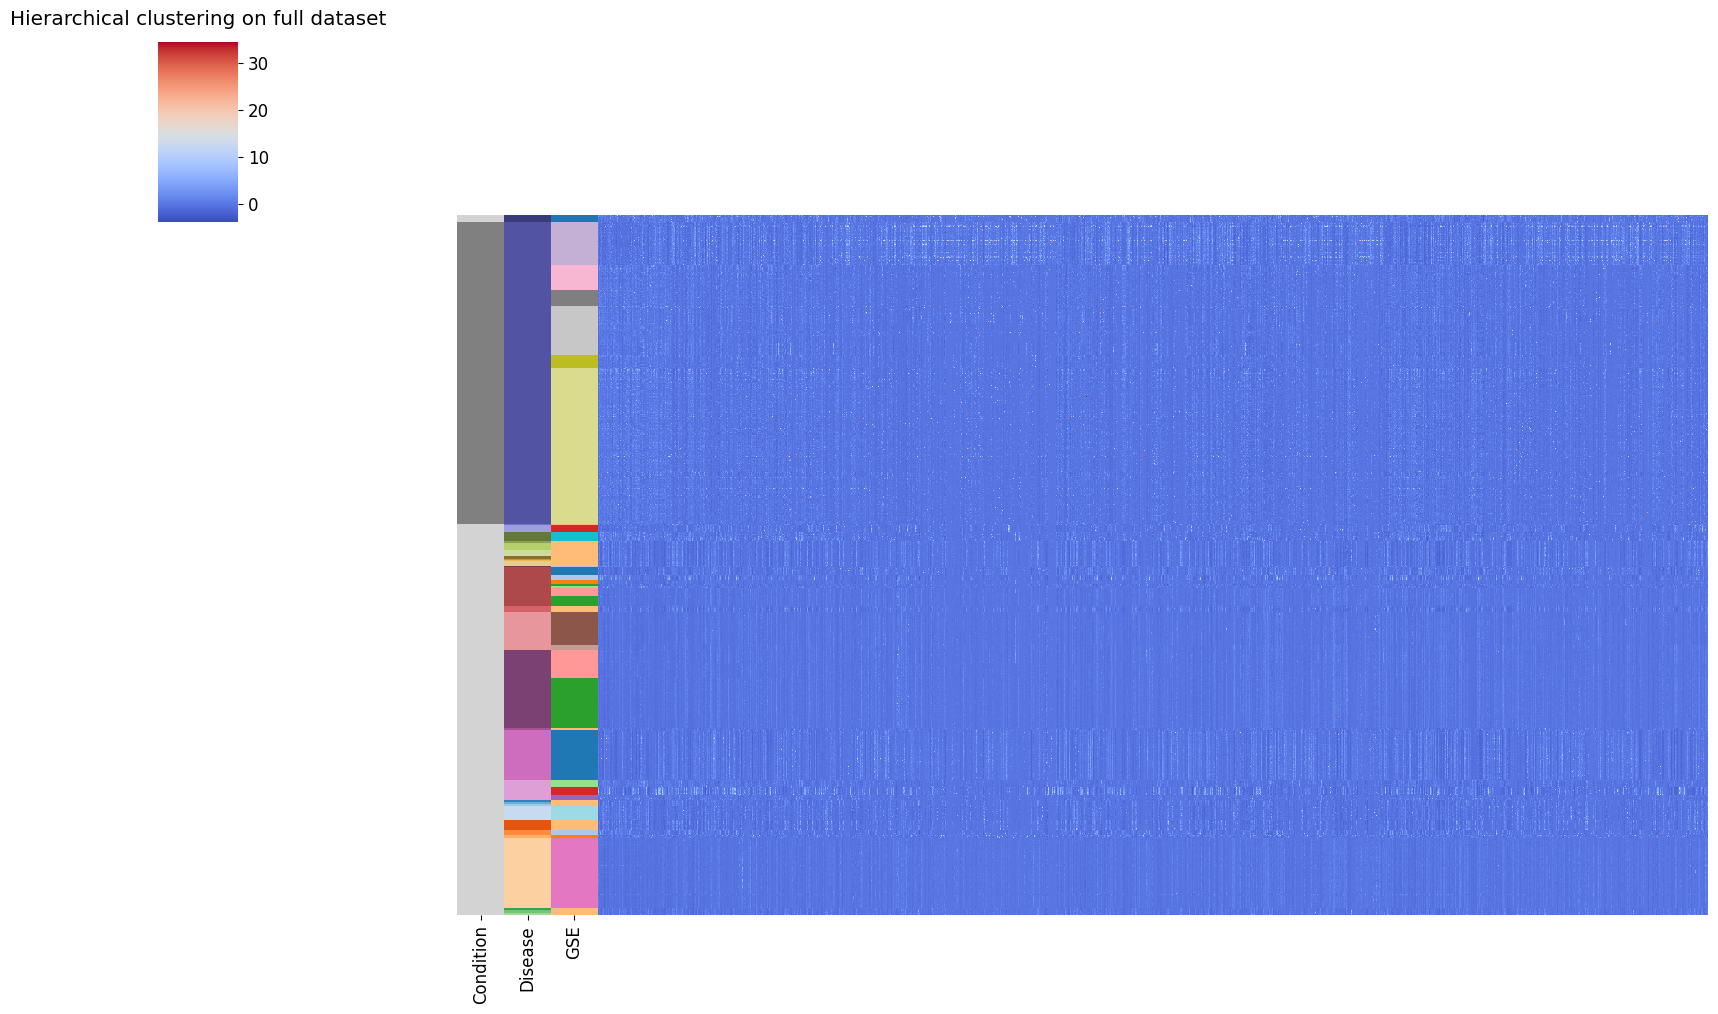

In [11]:
utils.hierarchical_clustering_heatmap(dataset3, name="case_study_1")

## Conclusion  

The exploratory data analysis (EDA) provides critical insights into the structure, balance, and potential biases in the RNA-Seq dataset:

* **Class Balance**: The dataset contains **1,181 samples** and is moderately imbalanced, with approximately **57% non-AML** and **43% AML** samples.  

* **High Dimensionality (p >> n)**: The dataset comprises over **12,000 gene expression features**, while the total number of samples is **1,181**. This high-dimensional setting increases the risk of overfitting, may lead to unstable feature importance estimates, and requires careful validation strategies to ensure robust and generalizable models.

* **Tissue Distribution**: The samples are drawn from two main tissue sources (**Bone Marrow (BM)** and **Peripheral Blood Mononuclear Cells (PBMC)**) with a majority from PBMCs (~70%). This unequal distribution suggests that **tissue type could act as a confounding variable**, especially in expression-based classification tasks.

* **Study Origin & Disease Diversity**: The data originates from more than 20 independent studies (GSEs) and includes a diverse range of disease types. This introduces potential **batch effects** and study-specific technical variation, which are critical when evaluating generalizability across unseen cohorts.

* **UMAP & PCA Visualizations**: Dimensionality reduction reveals visible clustering patterns when colored by `Condition`, `Tissue`, and `Disease`. Samples group according to both biological and technical labels, with partial overlaps between disease groups and studies—indicating that both biological variation and technical artifacts shape the latent space.

* **Hierarchical Clustering**: The heatmap further supports these findings by showing structured co-expression blocks aligned with metadata annotations. Samples from the same condition or disease group frequently cluster together, reinforcing the presence of meaningful biological signal, while also reflecting study-related structure.

Together, these results highlight the importance of accounting for **high dimensionality**, **study-specific effects**, **tissue origin**, and **disease composition** when interpreting model performance or explanations. They confirm the presence of biologically meaningful signal, but also emphasize that careful validation (e.g., cross-study splitting) is essential to control for confounding factors during modeling.